# Unidad 3: Regresión y Correlación
## Métodos de Análisis de Datos 1

**Universidad Nacional del Sur**  
Primer Semestre 2026

---

Este notebook cubre los contenidos prácticos de la Unidad 3:
- Regresión lineal simple
- Diagnóstico del modelo
- Regresión lineal múltiple
- Selección de variables
- Regresión polinomial
- Correlación
- ANCOVA

In [2]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Regresión
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

---
## 1. Regresión Lineal Simple

Comenzamos con un dataset simple de horas de estudio vs calificación.

In [3]:
# Crear datos sintéticos
np.random.seed(123)
n = 50
horas_estudio = np.random.uniform(1, 10, n)
calificacion = 40 + 5 * horas_estudio + np.random.normal(0, 5, n)

datos = pd.DataFrame({
    'horas': horas_estudio,
    'calificacion': calificacion
})

print(datos.head())
print(f"\nDimensiones: {datos.shape}")

      horas  calificacion
0  7.268223     81.234793
1  3.575254     69.066987
2  3.041663     48.737889
3  5.961833     64.615224
4  7.475221     86.094665

Dimensiones: (50, 2)


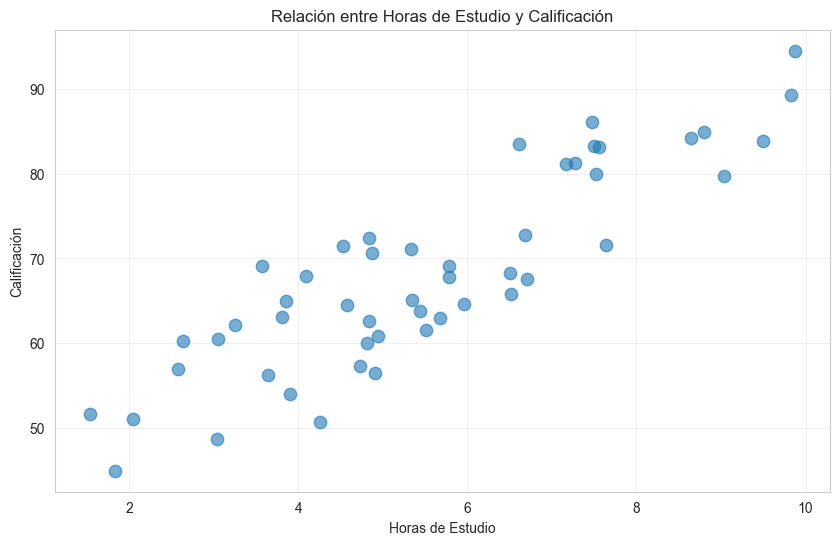

In [4]:
# Visualización inicial
plt.figure(figsize=(10, 6))
plt.scatter(datos['horas'], datos['calificacion'], alpha=0.6, s=80)
plt.xlabel('Horas de Estudio')
plt.ylabel('Calificación')
plt.title('Relación entre Horas de Estudio y Calificación')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Ajustar modelo de regresión lineal simple
modelo_simple = ols('calificacion ~ horas', data=datos).fit()

# Resumen completo
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:           calificacion   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     158.7
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           7.89e-17
Time:                        17:29:30   Log-Likelihood:                -156.56
No. Observations:                  50   AIC:                             317.1
Df Residuals:                      48   BIC:                             321.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5425      2.256     18.417      0.0

In [6]:
# Extraer componentes clave
print("=" * 50)
print("COMPONENTES CLAVE DEL MODELO")
print("=" * 50)

print(f"\nIntercepto: {modelo_simple.params['Intercept']:.3f}")
print(f"Pendiente: {modelo_simple.params['horas']:.3f}")
print(f"\nR²: {modelo_simple.rsquared:.4f}")
print(f"R² ajustado: {modelo_simple.rsquared_adj:.4f}")
print(f"\nAIC: {modelo_simple.aic:.2f}")
print(f"BIC: {modelo_simple.bic:.2f}")

print(f"\nError estándar residual: {np.sqrt(modelo_simple.mse_resid):.3f}")
print(f"F-estadístico: {modelo_simple.fvalue:.2f}")
print(f"p-valor (F): {modelo_simple.f_pvalue:.4e}")

COMPONENTES CLAVE DEL MODELO

Intercepto: 41.543
Pendiente: 4.816

R²: 0.7677
R² ajustado: 0.7629

AIC: 317.13
BIC: 320.95

Error estándar residual: 5.656
F-estadístico: 158.67
p-valor (F): 7.8871e-17


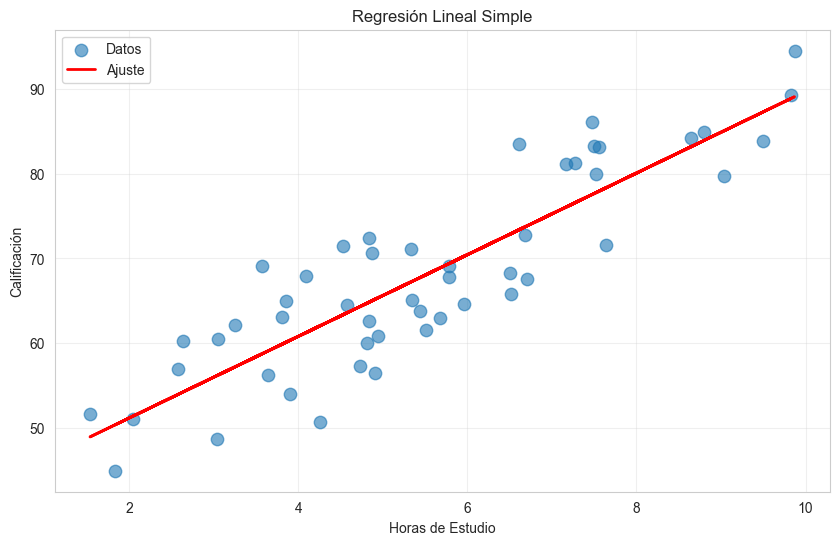

In [7]:
# Visualizar ajuste
plt.figure(figsize=(10, 6))
plt.scatter(datos['horas'], datos['calificacion'], alpha=0.6, s=80, label='Datos')
plt.plot(datos['horas'], modelo_simple.fittedvalues, 'r-', linewidth=2, label='Ajuste')
plt.xlabel('Horas de Estudio')
plt.ylabel('Calificación')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Predicción con intervalos
nuevos_datos = pd.DataFrame({'horas': [3, 5, 7]})

# Predicción puntual
pred = modelo_simple.predict(nuevos_datos)
print("Predicciones puntuales:")
print(pred)

# Con intervalos
pred_obj = modelo_simple.get_prediction(nuevos_datos)
intervalos = pred_obj.summary_frame(alpha=0.05)
print("\nPredicciones con intervalos:")
print(intervalos)

Predicciones puntuales:
0    55.989945
1    65.621572
2    75.253199
dtype: float64

Predicciones con intervalos:
        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  55.989945  1.251254      53.474131      58.505759     44.342471   
1  65.621572  0.823939      63.964932      67.278212     54.129018   
2  75.253199  0.980524      73.281724      77.224675     63.711057   

   obs_ci_upper  
0     67.637419  
1     77.114126  
2     86.795341  


---
## 2. Diagnóstico del Modelo

Verificamos los supuestos del modelo mediante gráficos de residuos.

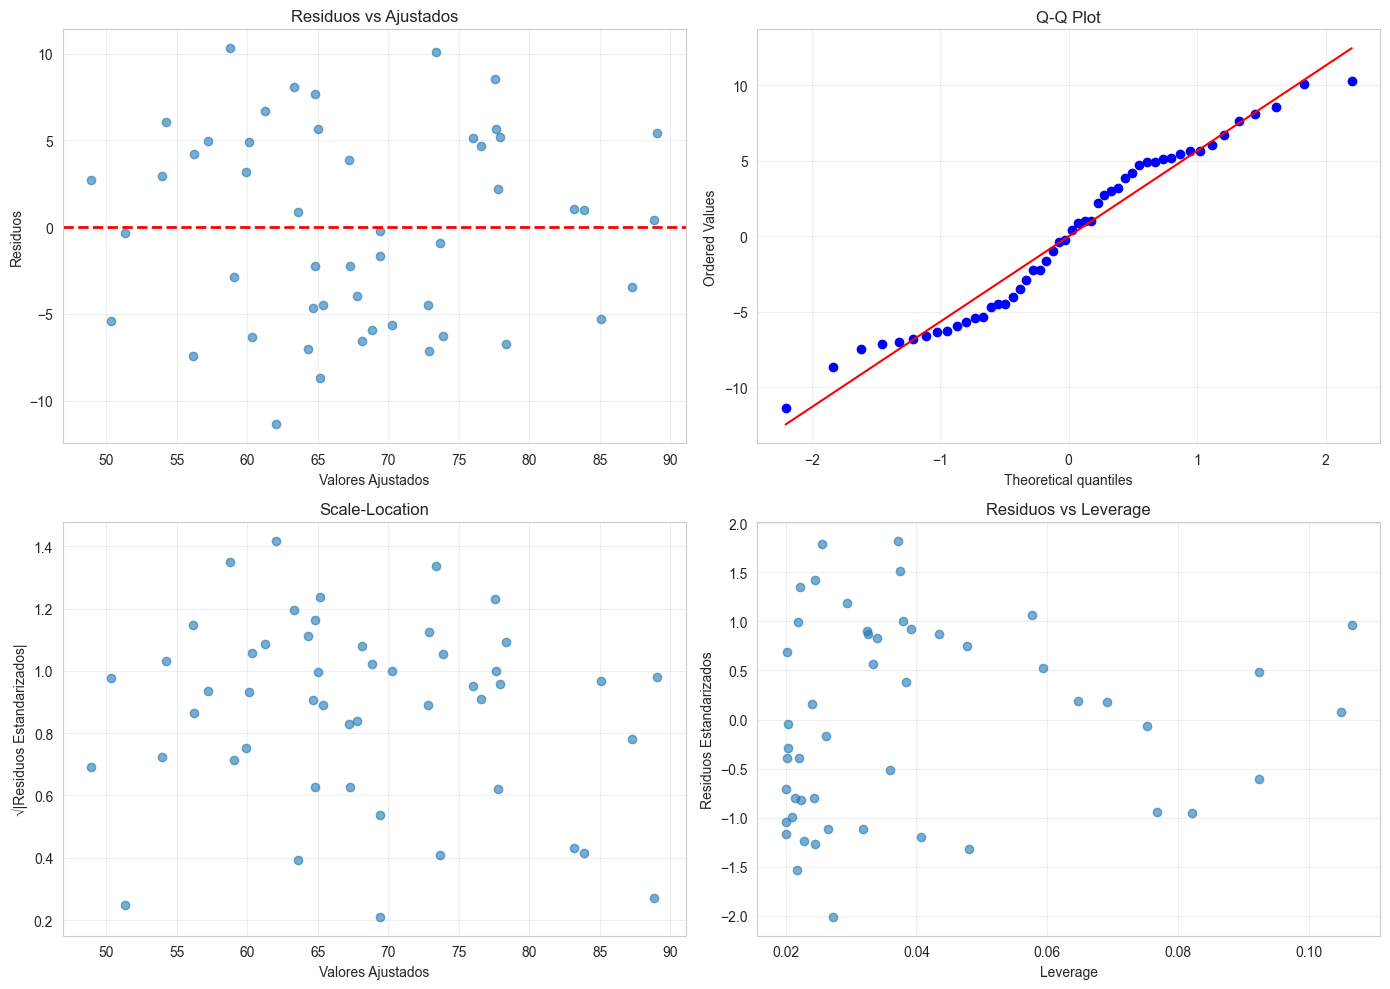

In [9]:
# Gráficos de diagnóstico (los 4 principales)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Ajustados
axes[0, 0].scatter(modelo_simple.fittedvalues, modelo_simple.resid, alpha=0.6)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Ajustados')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot
stats.probplot(modelo_simple.resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Scale-Location
residuos_std = np.sqrt(np.abs(modelo_simple.resid_pearson))
axes[1, 0].scatter(modelo_simple.fittedvalues, residuos_std, alpha=0.6)
axes[1, 0].set_xlabel('Valores Ajustados')
axes[1, 0].set_ylabel('√|Residuos Estandarizados|')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuos vs Leverage
influence = modelo_simple.get_influence()
leverage = influence.hat_matrix_diag
axes[1, 1].scatter(leverage, modelo_simple.resid_pearson, alpha=0.6)
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Residuos Estandarizados')
axes[1, 1].set_title('Residuos vs Leverage')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Tests formales
print("=" * 50)
print("TESTS DE SUPUESTOS")
print("=" * 50)

# Test de Shapiro-Wilk (normalidad)
stat_sw, p_sw = stats.shapiro(modelo_simple.resid)
print(f"\nShapiro-Wilk (normalidad):")
print(f"  Estadístico: {stat_sw:.4f}")
print(f"  p-valor: {p_sw:.4f}")
print(f"  Conclusión: {'Rechazamos normalidad' if p_sw < 0.05 else 'No rechazamos normalidad'} (α=0.05)")

# Test de Breusch-Pagan (homocedasticidad)
bp_test = het_breuschpagan(modelo_simple.resid, modelo_simple.model.exog)
print(f"\nBreusch-Pagan (homocedasticidad):")
print(f"  LM estadístico: {bp_test[0]:.4f}")
print(f"  p-valor: {bp_test[1]:.4f}")
print(f"  Conclusión: {'Rechazamos homocedasticidad' if bp_test[1] < 0.05 else 'No rechazamos homocedasticidad'} (α=0.05)")

# Test de Durbin-Watson (autocorrelación)
dw = durbin_watson(modelo_simple.resid)
print(f"\nDurbin-Watson (autocorrelación):")
print(f"  DW: {dw:.4f}")
print(f"  Interpretación: {'Autocorrelación positiva' if dw < 1.5 else 'No autocorrelación' if dw < 2.5 else 'Autocorrelación negativa'}")

TESTS DE SUPUESTOS

Shapiro-Wilk (normalidad):
  Estadístico: 0.9585
  p-valor: 0.0772
  Conclusión: No rechazamos normalidad (α=0.05)

Breusch-Pagan (homocedasticidad):
  LM estadístico: 0.6220
  p-valor: 0.4303
  Conclusión: No rechazamos homocedasticidad (α=0.05)

Durbin-Watson (autocorrelación):
  DW: 2.1450
  Interpretación: No autocorrelación


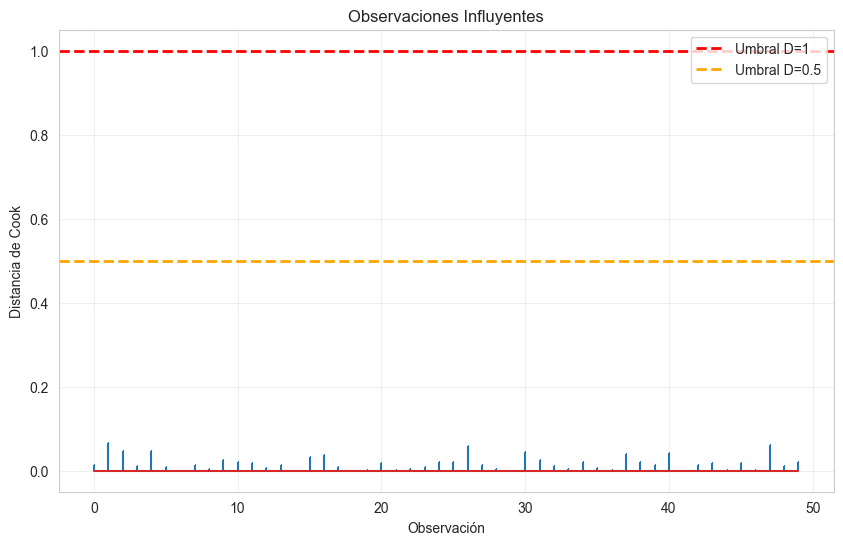


Observaciones con D > 1: Ninguna
Observaciones con 0.5 < D ≤ 1: Ninguna


In [11]:
# Distancia de Cook (observaciones influyentes)
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 6))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=',')
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Umbral D=1')
plt.axhline(0.5, color='orange', linestyle='--', linewidth=2, label='Umbral D=0.5')
plt.xlabel('Observación')
plt.ylabel("Distancia de Cook")
plt.title('Observaciones Influyentes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

influyentes = np.where(cooks_d > 1)[0]
print(f"\nObservaciones con D > 1: {influyentes if len(influyentes) > 0 else 'Ninguna'}")
moderadas = np.where((cooks_d > 0.5) & (cooks_d <= 1))[0]
print(f"Observaciones con 0.5 < D ≤ 1: {moderadas if len(moderadas) > 0 else 'Ninguna'}")

---
## 3. Regresión Lineal Múltiple

Extendemos el modelo con múltiples predictores.

In [12]:
# Crear dataset con múltiples predictores
np.random.seed(456)
n = 100

metros = np.random.uniform(50, 200, n)
habitaciones = np.random.randint(1, 6, n)
antiguedad = np.random.uniform(0, 50, n)

# Precio con relación múltiple
precio = 50 + 1.2*metros + 5*habitaciones - 0.8*antiguedad + np.random.normal(0, 20, n)

casas = pd.DataFrame({
    'precio': precio,
    'metros': metros,
    'habitaciones': habitaciones,
    'antiguedad': antiguedad
})

print(casas.head())
print(f"\nCorrelaciones con precio:")
print(casas.corr()['precio'].sort_values(ascending=False))

       precio      metros  habitaciones  antiguedad
0  218.413752   87.313386             4   16.799781
1  134.890981   74.460017             1   34.013751
2  248.669874  167.546488             1   36.711295
3  258.608237  171.278508             1   19.257625
4  258.149420  143.844264             4   26.499785

Correlaciones con precio:
precio          1.000000
metros          0.902096
habitaciones    0.082114
antiguedad     -0.220754
Name: precio, dtype: float64


In [13]:
# Ajustar modelo múltiple
modelo_multiple = ols('precio ~ metros + habitaciones + antiguedad', 
                      data=casas).fit()

print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                 precio   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     239.4
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           2.00e-44
Time:                        17:29:30   Log-Likelihood:                -438.85
No. Observations:                 100   AIC:                             885.7
Df Residuals:                      96   BIC:                             896.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       46.2601      9.021      5.128   

In [14]:
# Comparar con modelos simples
print("=" * 60)
print("COMPARACIÓN DE MODELOS")
print("=" * 60)

m1 = ols('precio ~ metros', data=casas).fit()
m2 = ols('precio ~ metros + habitaciones', data=casas).fit()
m3 = modelo_multiple

comparacion = pd.DataFrame({
    'Modelo': ['Solo metros', '+ habitaciones', '+ antiguedad'],
    'R²': [m1.rsquared, m2.rsquared, m3.rsquared],
    'R² ajustado': [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    'AIC': [m1.aic, m2.aic, m3.aic],
    'BIC': [m1.bic, m2.bic, m3.bic]
})

print("\n", comparacion.to_string(index=False))
print("\nMejor modelo por AIC:", comparacion.loc[comparacion['AIC'].idxmin(), 'Modelo'])
print("Mejor modelo por BIC:", comparacion.loc[comparacion['BIC'].idxmin(), 'Modelo'])

COMPARACIÓN DE MODELOS

         Modelo       R²  R² ajustado        AIC        BIC
   Solo metros 0.813778     0.811878 927.423580 932.633920
+ habitaciones 0.848090     0.844957 909.058709 916.874219
  + antiguedad 0.882108     0.878424 885.706118 896.126799

Mejor modelo por AIC: + antiguedad
Mejor modelo por BIC: + antiguedad


In [15]:
# Tabla ANOVA
print("\nTabla ANOVA (Tipo II):")
print(anova_lm(modelo_multiple, typ=2))


Tabla ANOVA (Tipo II):
                     sum_sq    df           F        PR(>F)
metros        267632.363596   1.0  676.791622  2.883199e-45
habitaciones    7529.833144   1.0   19.041524  3.222514e-05
antiguedad     10954.489990   1.0   27.701833  8.617062e-07
Residual       37962.507336  96.0         NaN           NaN


In [16]:
# Calcular VIF (multicolinealidad)
X = casas[['metros', 'habitaciones', 'antiguedad']]
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n" + "=" * 40)
print("FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 40)
print(vif_data.to_string(index=False))
print("\nInterpretación:")
print("  VIF < 5: Multicolinealidad baja")
print("  5 ≤ VIF < 10: Multicolinealidad moderada")
print("  VIF ≥ 10: Multicolinealidad severa")


FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
    Variable      VIF
      metros 4.714153
habitaciones 3.569278
  antiguedad 3.358747

Interpretación:
  VIF < 5: Multicolinealidad baja
  5 ≤ VIF < 10: Multicolinealidad moderada
  VIF ≥ 10: Multicolinealidad severa


---
## 4. Regresión Polinomial

Para relaciones no lineales.

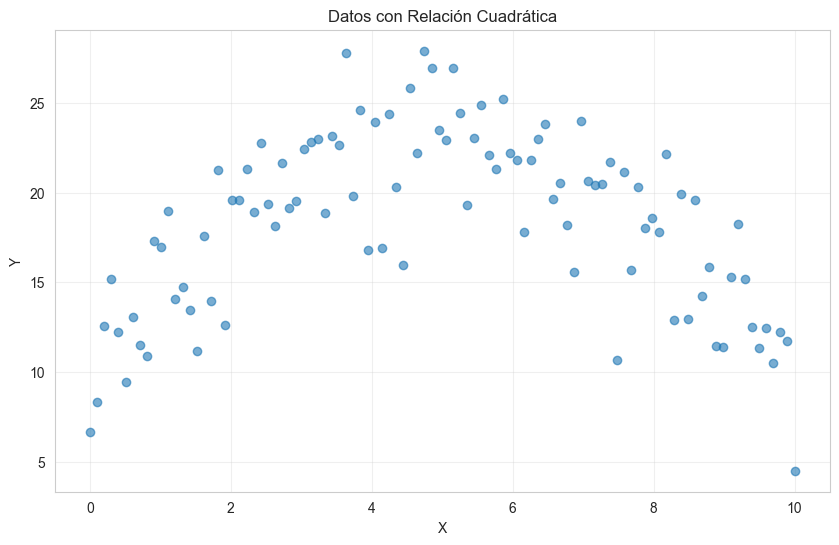

In [17]:
# Crear datos con relación cuadrática
np.random.seed(789)
x_poly = np.linspace(0, 10, 100)
y_poly = 10 + 5*x_poly - 0.5*x_poly**2 + np.random.normal(0, 3, 100)

datos_poly = pd.DataFrame({'x': x_poly, 'y': y_poly})

# Visualizar
plt.figure(figsize=(10, 6))
plt.scatter(datos_poly['x'], datos_poly['y'], alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos con Relación Cuadrática')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Ajustar modelos de distintos grados
modelo_lineal = ols('y ~ x', data=datos_poly).fit()
modelo_cuad = ols('y ~ x + I(x**2)', data=datos_poly).fit()
modelo_cubico = ols('y ~ x + I(x**2) + I(x**3)', data=datos_poly).fit()

# Comparar
comparacion_poly = pd.DataFrame({
    'Grado': [1, 2, 3],
    'R²': [modelo_lineal.rsquared, modelo_cuad.rsquared, modelo_cubico.rsquared],
    'R² ajustado': [modelo_lineal.rsquared_adj, modelo_cuad.rsquared_adj, modelo_cubico.rsquared_adj],
    'AIC': [modelo_lineal.aic, modelo_cuad.aic, modelo_cubico.aic],
    'BIC': [modelo_lineal.bic, modelo_cuad.bic, modelo_cubico.bic]
})

print(comparacion_poly.to_string(index=False))
print(f"\nMejor modelo: Grado {comparacion_poly.loc[comparacion_poly['AIC'].idxmin(), 'Grado']} (por AIC)")

 Grado       R²  R² ajustado        AIC        BIC
     1 0.000213    -0.009989 609.318432 614.528772
     2 0.672674     0.665925 499.659914 507.475424
     3 0.673791     0.663597 501.317907 511.738588

Mejor modelo: Grado 2 (por AIC)


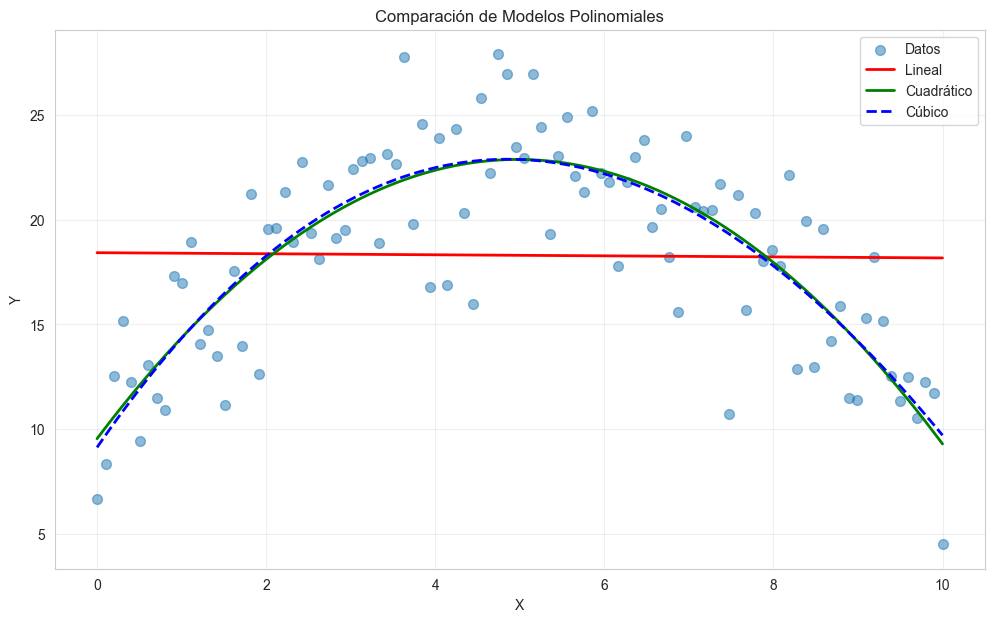

In [19]:
# Visualizar ajustes
x_seq = np.linspace(0, 10, 200)
pred_data = pd.DataFrame({'x': x_seq})

plt.figure(figsize=(12, 7))
plt.scatter(datos_poly['x'], datos_poly['y'], alpha=0.5, label='Datos', s=50)
plt.plot(x_seq, modelo_lineal.predict(pred_data), 'r-', linewidth=2, label='Lineal')
plt.plot(x_seq, modelo_cuad.predict(pred_data), 'g-', linewidth=2, label='Cuadrático')
plt.plot(x_seq, modelo_cubico.predict(pred_data), 'b--', linewidth=2, label='Cúbico')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Comparación de Modelos Polinomiales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Punto crítico del modelo cuadrático
beta0 = modelo_cuad.params['Intercept']
beta1 = modelo_cuad.params['x']
beta2 = modelo_cuad.params['I(x ** 2)']

x_critico = -beta1 / (2 * beta2)
y_critico = modelo_cuad.predict(pd.DataFrame({'x': [x_critico]}))[0]

print(f"\nModelo cuadrático: y = {beta0:.2f} + {beta1:.2f}x + {beta2:.2f}x²")
print(f"\nPunto crítico: x = {x_critico:.2f}")
print(f"Valor en el punto crítico: y = {y_critico:.2f}")
print(f"Tipo: {'Máximo' if beta2 < 0 else 'Mínimo'}")


Modelo cuadrático: y = 9.54 + 5.36x + -0.54x²

Punto crítico: x = 4.98
Valor en el punto crítico: y = 22.88
Tipo: Máximo


---
## 5. Correlación

Medidas de asociación entre variables.

MATRIZ DE CORRELACIÓN
                precio    metros  habitaciones  antiguedad
precio        1.000000  0.902096      0.082114   -0.220754
metros        0.902096  1.000000     -0.112996   -0.009708
habitaciones  0.082114 -0.112996      1.000000   -0.159813
antiguedad   -0.220754 -0.009708     -0.159813    1.000000


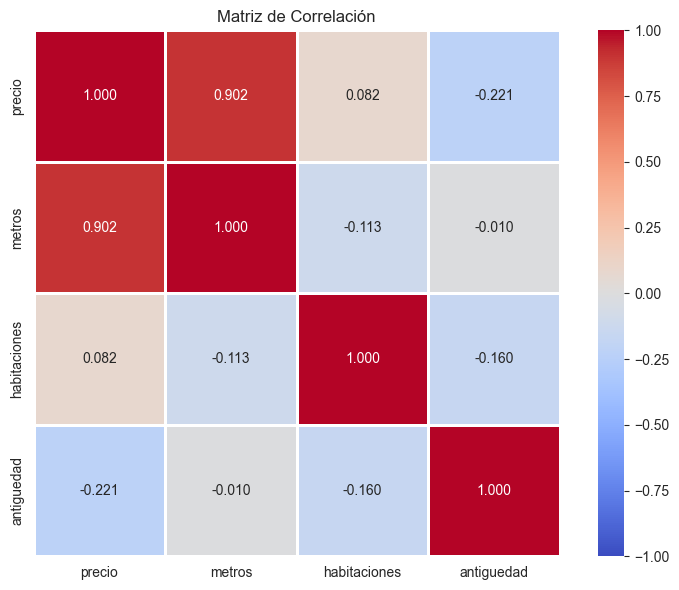

In [21]:
# Usar dataset de casas
print("=" * 50)
print("MATRIZ DE CORRELACIÓN")
print("=" * 50)
print(casas.corr())

# Visualizar con heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(casas.corr(), annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=1)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

In [22]:
# Tests de correlación
print("\n" + "=" * 50)
print("TESTS DE CORRELACIÓN: Precio vs Metros")
print("=" * 50)

# Pearson
r_pearson, p_pearson = stats.pearsonr(casas['precio'], casas['metros'])
print(f"\nPearson:")
print(f"  r = {r_pearson:.4f}")
print(f"  p-valor = {p_pearson:.4f}")
print(f"  Conclusión: {'Correlación significativa' if p_pearson < 0.05 else 'No significativa'} (α=0.05)")

# Spearman
r_spearman, p_spearman = stats.spearmanr(casas['precio'], casas['metros'])
print(f"\nSpearman:")
print(f"  ρ = {r_spearman:.4f}")
print(f"  p-valor = {p_spearman:.4f}")
print(f"  Conclusión: {'Correlación significativa' if p_spearman < 0.05 else 'No significativa'} (α=0.05)")


TESTS DE CORRELACIÓN: Precio vs Metros

Pearson:
  r = 0.9021
  p-valor = 0.0000
  Conclusión: Correlación significativa (α=0.05)

Spearman:
  ρ = 0.9041
  p-valor = 0.0000
  Conclusión: Correlación significativa (α=0.05)


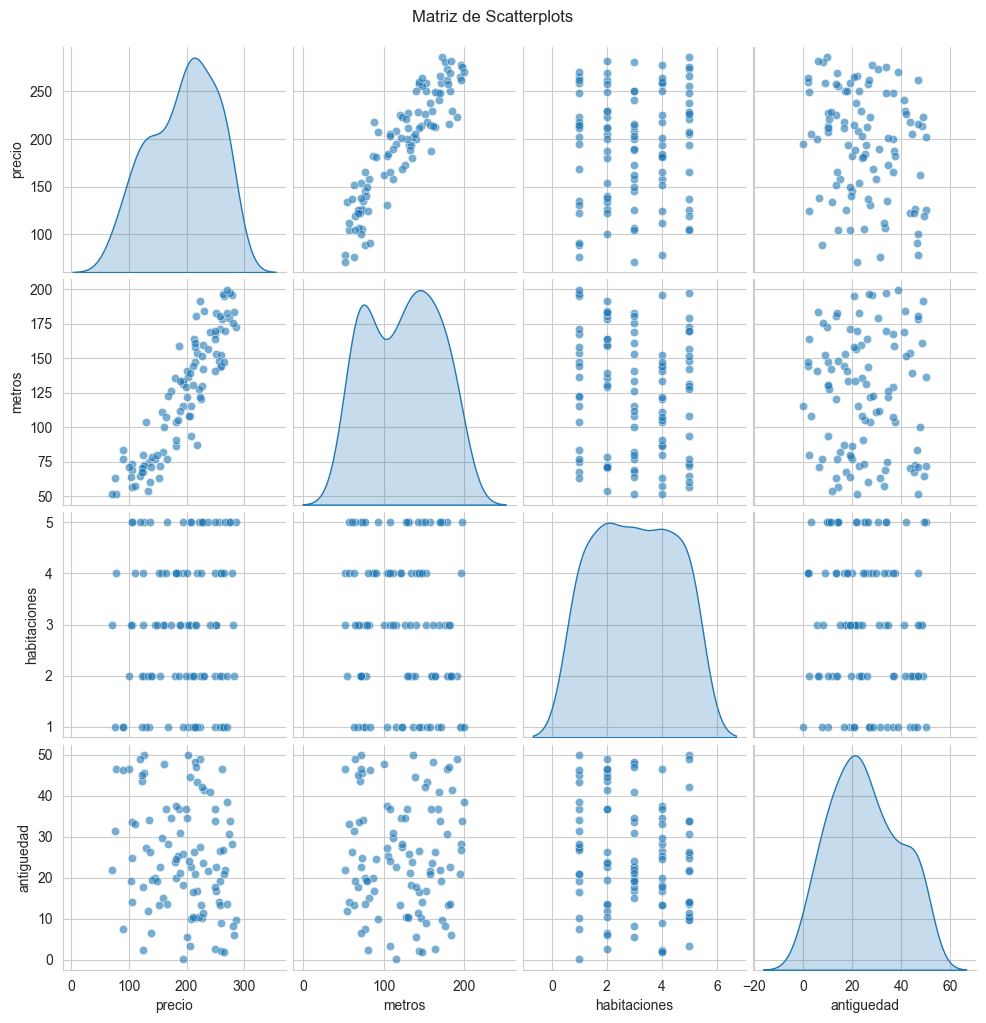

In [23]:
# Scatterplot matrix
sns.pairplot(casas, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Matriz de Scatterplots', y=1.02)
plt.show()

---
## 6. ANCOVA

Análisis de Covarianza: comparar grupos ajustando por covariable.

In [24]:
# Crear datos de ejemplo: efecto de 3 dietas
np.random.seed(101)
n_por_grupo = 20

# Grupo A
peso_ini_A = np.random.normal(80, 10, n_por_grupo)
peso_fin_A = 0.9 * peso_ini_A + np.random.normal(-5, 3, n_por_grupo)

# Grupo B
peso_ini_B = np.random.normal(82, 10, n_por_grupo)
peso_fin_B = 0.9 * peso_ini_B + np.random.normal(-8, 3, n_por_grupo)

# Grupo C
peso_ini_C = np.random.normal(81, 10, n_por_grupo)
peso_fin_C = 0.9 * peso_ini_C + np.random.normal(-3, 3, n_por_grupo)

datos_dieta = pd.DataFrame({
    'peso_inicial': np.concatenate([peso_ini_A, peso_ini_B, peso_ini_C]),
    'peso_final': np.concatenate([peso_fin_A, peso_fin_B, peso_fin_C]),
    'dieta': ['A']*n_por_grupo + ['B']*n_por_grupo + ['C']*n_por_grupo
})

print(datos_dieta.groupby('dieta').describe())

      peso_inicial                                                         \
             count       mean        std        min        25%        50%   
dieta                                                                       
A             20.0  84.204452  11.636770  59.818318  76.132613  85.673894   
B             20.0  82.831272   9.455012  70.633554  75.534745  81.843937   
C             20.0  79.830669   9.688867  61.273949  72.418817  78.231543   

                             peso_final                                   \
             75%         max      count       mean        std        min   
dieta                                                                      
A      87.820839  107.068498       20.0  71.368603  11.370534  51.259604   
B      88.203149  103.548464       20.0  67.299179   9.340567  52.455307   
C      87.479340   96.419904       20.0  68.649774   8.615303  55.073713   

                                                   
             25%        50% 

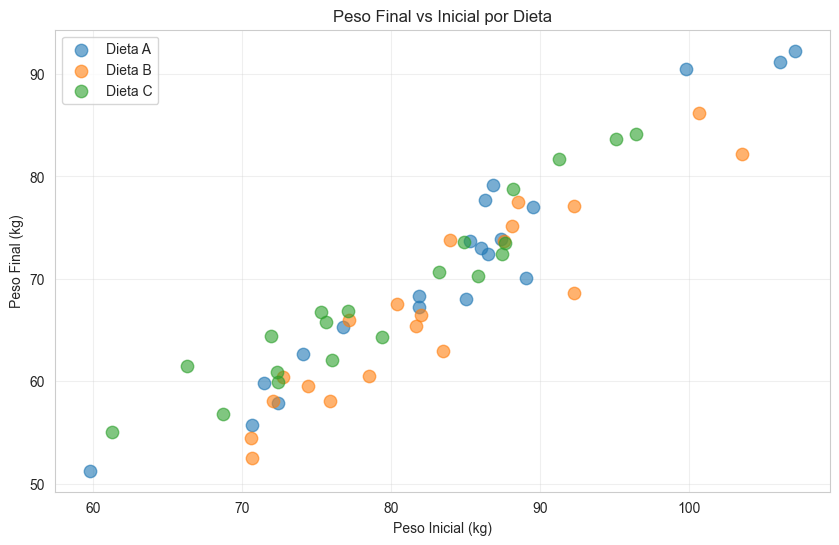

In [25]:
# Visualizar datos
plt.figure(figsize=(10, 6))
for dieta in ['A', 'B', 'C']:
    subset = datos_dieta[datos_dieta['dieta'] == dieta]
    plt.scatter(subset['peso_inicial'], subset['peso_final'], 
                label=f'Dieta {dieta}', alpha=0.6, s=80)
plt.xlabel('Peso Inicial (kg)')
plt.ylabel('Peso Final (kg)')
plt.title('Peso Final vs Inicial por Dieta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# Test de pendientes paralelas (interacción)
modelo_interaccion = ols('peso_final ~ C(dieta) * peso_inicial', 
                         data=datos_dieta).fit()

print("=" * 50)
print("TEST DE PENDIENTES PARALELAS")
print("=" * 50)
print(anova_lm(modelo_interaccion, typ=2))

p_interaccion = anova_lm(modelo_interaccion, typ=2).loc['C(dieta):peso_inicial', 'PR(>F)']
print(f"\np-valor de interacción: {p_interaccion:.4f}")
print(f"Conclusión: {'Rechazamos pendientes paralelas' if p_interaccion < 0.05 else 'No rechazamos pendientes paralelas'} (α=0.05)")

if p_interaccion >= 0.05:
    print("\n✓ Supuesto cumplido: podemos usar ANCOVA")
else:
    print("\n✗ Supuesto violado: ANCOVA no apropiado")

TEST DE PENDIENTES PARALELAS
                            sum_sq    df           F        PR(>F)
C(dieta)                173.170269   2.0    9.221521  3.586917e-04
peso_inicial           5007.237721   1.0  533.282602  1.173963e-29
C(dieta):peso_inicial    10.145869   2.0    0.540279  5.857016e-01
Residual                507.031049  54.0         NaN           NaN

p-valor de interacción: 0.5857
Conclusión: No rechazamos pendientes paralelas (α=0.05)

✓ Supuesto cumplido: podemos usar ANCOVA


In [27]:
# Modelo ANCOVA (sin interacción)
modelo_ancova = ols('peso_final ~ C(dieta) + peso_inicial', 
                    data=datos_dieta).fit()

print("\n" + "=" * 50)
print("MODELO ANCOVA")
print("=" * 50)
print(modelo_ancova.summary())

print("\n" + "=" * 50)
print("TABLA ANOVA (Tipo II)")
print("=" * 50)
print(anova_lm(modelo_ancova, typ=2))


MODELO ANCOVA
                            OLS Regression Results                            
Dep. Variable:             peso_final   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     186.9
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           3.87e-29
Time:                        17:29:32   Log-Likelihood:                -149.76
No. Observations:                  60   AIC:                             307.5
Df Residuals:                      56   BIC:                             315.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -5.2045      3

In [28]:
# Comparar con ANOVA sin covariable
modelo_anova = ols('peso_final ~ C(dieta)', data=datos_dieta).fit()

print("\n" + "=" * 50)
print("COMPARACIÓN: ANOVA vs ANCOVA")
print("=" * 50)

comp = pd.DataFrame({
    'Modelo': ['ANOVA (sin covariable)', 'ANCOVA (con covariable)'],
    'R²': [modelo_anova.rsquared, modelo_ancova.rsquared],
    'Error Std': [np.sqrt(modelo_anova.mse_resid), np.sqrt(modelo_ancova.mse_resid)]
})

print(comp.to_string(index=False))
print(f"\nReducción del error: {(1 - np.sqrt(modelo_ancova.mse_resid)/np.sqrt(modelo_anova.mse_resid))*100:.1f}%")


COMPARACIÓN: ANOVA vs ANCOVA
                 Modelo       R²  Error Std
 ANOVA (sin covariable) 0.030168   9.844773
ANCOVA (con covariable) 0.909208   3.038964

Reducción del error: 69.1%


---
## Resumen Final

### Funciones Python principales usadas:

| Tarea | Función | Librería |
|-------|---------|----------|
| Regresión | `ols()`, `.fit()` | statsmodels |
| Diagnóstico | `plot()`, `probplot()` | matplotlib, scipy |
| Tests | `shapiro()`, `het_breuschpagan()`, `durbin_watson()` | scipy, statsmodels |
| VIF | `variance_inflation_factor()` | statsmodels |
| ANOVA | `anova_lm()` | statsmodels |
| Correlación | `pearsonr()`, `spearmanr()` | scipy |
| Visualización | `scatter()`, `heatmap()`, `pairplot()` | matplotlib, seaborn |

### Criterios de selección:
- **AIC/BIC:** Menor es mejor
- **R² ajustado:** Mayor es mejor (penaliza complejidad)
- **VIF:** < 5 OK, > 10 multicolinealidad severa
- **Cook's D:** > 1 muy influyente, > 0.5 moderadamente influyente